<a href="https://colab.research.google.com/github/rawalnidhi/skin-cancer-xai-ham10000/blob/main/notebooks/02_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Baselines (HAM10000)

In this notebook, we establish baseline performance and a clean preprocessing pipeline.

- Preprocessing pipeline: cleaning, normalization, splits, augmentation
- Baselines:
  1) Naive baseline (random + majority class)
  2) Simple model baseline (logistic regression)
- Then we train a simple CNN baseline (our “simple NN” baseline for images) and ensure it beats naive baselines.

In [1]:
# =========================
# Imports
# =========================
import os
import random
from pathlib import Path
import time
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

## Reproducibility + Device
We set seeds for reproducibility and choose GPU.

In [2]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


## Project Paths (Google Drive)
We use Drive as the persistent storage so we do not re-download data each session.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

# ✅ Set this to your project folder on Drive
PROJECT_ROOT = "/content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000"

PROJECT_ROOT = Path(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "ham10000"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ PROJECT_ROOT:", PROJECT_ROOT)
print("✅ DATA_DIR:", DATA_DIR)
print("✅ MODELS_DIR:", MODELS_DIR)

Mounted at /content/drive
✅ PROJECT_ROOT: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000
✅ DATA_DIR: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/data/raw/ham10000
✅ MODELS_DIR: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models


In [4]:
# =========================
# Kaggle download (only if needed)
# =========================

metadata_path = DATA_DIR / "HAM10000_metadata.csv"
zip_path = DATA_DIR / "skin-cancer-mnist-ham10000.zip"

if not metadata_path.exists():
    print("📥 Metadata not found. Downloading dataset from Kaggle...")

    # Install kaggle CLI if needed
    !pip -q install kaggle

    # Option A (recommended): Use Colab Secrets
    # - Add secrets in Colab (🔑 icon):
    #   KAGGLE_USERNAME = your kaggle username
    #   KAGGLE_KEY      = your kaggle api key
    #
    # Code reads them without printing.
    from google.colab import userdata
    kaggle_username = userdata.get("KAGGLE_USERNAME")
    kaggle_key = userdata.get("KAGGLE_KEY")

    if (kaggle_username is None) or (kaggle_key is None):
        raise ValueError(
            "Missing KAGGLE_USERNAME or KAGGLE_KEY in Colab Secrets (🔑). "
            "Add them, then rerun this cell."
        )

    # Write kaggle.json into the runtime (NOT into GitHub / Drive)
    os.makedirs("/root/.kaggle", exist_ok=True)
    with open("/root/.kaggle/kaggle.json", "w") as f:
        json.dump({"username": kaggle_username, "key": kaggle_key}, f)
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

    # Download + unzip to Drive folder
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p "{DATA_DIR}"
    !unzip -q "{DATA_DIR}/skin-cancer-mnist-ham10000.zip" -d "{DATA_DIR}"

    print("✅ Dataset downloaded and extracted to Drive.")
else:
    print("✅ Dataset already exists on Drive. Skipping download.")

✅ Dataset already exists on Drive. Skipping download.


## Load Metadata and Resolve Image Paths

HAM10000 images are stored in **two folders** (`HAM10000_images_part_1` and `HAM10000_images_part_2`).  
The metadata file (`HAM10000_metadata.csv`) contains `image_id` values, so we:

1. Load the metadata
2. Check that the two image folders exist
3. Build a single `image_path` column for every row
4. Verify that **all 10,015 images** resolve successfully (no missing paths)

# Preprocessing pipeline
We build a clean pipeline that includes:
- Data cleaning (verify paths, remove missing, handle missing metadata if used)
- Feature engineering (if applicable — for baselines we keep images; later we can add metadata features)
- Normalization/standardization
- Train/validation/test splits (stratified)
- Data augmentation setup

In [5]:
# =========================
# Load metadata
# =========================
metadata = pd.read_csv(metadata_path)
print("✅ Metadata loaded:", metadata.shape)
display(metadata.head())

# Image folders
img_dir_1 = DATA_DIR / "HAM10000_images_part_1"
img_dir_2 = DATA_DIR / "HAM10000_images_part_2"

print("Folder 1 exists:", img_dir_1.exists(), "|", img_dir_1)
print("Folder 2 exists:", img_dir_2.exists(), "|", img_dir_2)

# Helper to resolve image path from image_id
def resolve_image_path(image_id: str) -> Path:
    p1 = img_dir_1 / f"{image_id}.jpg"
    if p1.exists():
        return p1
    p2 = img_dir_2 / f"{image_id}.jpg"
    return p2

metadata["image_path"] = metadata["image_id"].apply(lambda x: str(resolve_image_path(x)))
metadata["image_exists"] = metadata["image_path"].apply(lambda p: Path(p).exists())

missing_paths = (~metadata["image_exists"]).sum()
print("❗ Missing image paths:", missing_paths)
if missing_paths > 0:
    metadata = metadata[metadata["image_exists"]].copy()
    print("✅ Dropped missing images. New shape:", metadata.shape)

# Cleaning: keep only required columns for image classification baseline
df = metadata[["image_id", "dx", "image_path"]].copy()

# Ensure dx is valid and non-null
df = df.dropna(subset=["dx", "image_path"]).reset_index(drop=True)

# Label encoding
classes = sorted(df["dx"].unique().tolist())
label_map = {c: i for i, c in enumerate(classes)}
df["label"] = df["dx"].map(label_map).astype(int)

print("✅ Classes:", classes)
print("✅ Label map:", label_map)
print("✅ Total rows:", len(df))
print("Example image path:", df.loc[0, "image_path"])

✅ Metadata loaded: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Folder 1 exists: True | /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/data/raw/ham10000/HAM10000_images_part_1
Folder 2 exists: True | /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/data/raw/ham10000/HAM10000_images_part_2
❗ Missing image paths: 0
✅ Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
✅ Label map: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
✅ Total rows: 10015
Example image path: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/data/raw/ham10000/HAM10000_images_part_1/ISIC_0027419.jpg


## Train / Validation / Test Split (Stratified)

Because HAM10000 is **class-imbalanced**, a random split can accidentally put too many minority-class samples into one split.

We use a **stratified split** so train/val/test each contain a similar proportion of every diagnosis class (`dx`).

Split plan:
- **80% Train**
- **10% Validation**
- **10% Test**

We also fix a random seed so the split is **reproducible** every run.

In [6]:
# =========================
# Splits
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("\n✅ Split sizes:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

def show_dist(name, split_df):
    dist = split_df["dx"].value_counts(normalize=True)
    print(f"\n{name} class distribution (proportions):")
    print(dist.sort_index())

show_dist("Train", train_df)
show_dist("Val", val_df)
show_dist("Test", test_df)


✅ Split sizes:
Train: 8012
Val:   1001
Test:  1002

Train class distribution (proportions):
dx
akiec    0.032701
bcc      0.051298
bkl      0.109710
df       0.011483
mel      0.111083
nv       0.669496
vasc     0.014229
Name: proportion, dtype: float64

Val class distribution (proportions):
dx
akiec    0.032967
bcc      0.050949
bkl      0.109890
df       0.011988
mel      0.110889
nv       0.669331
vasc     0.013986
Name: proportion, dtype: float64

Test class distribution (proportions):
dx
akiec    0.031936
bcc      0.051896
bkl      0.109780
df       0.010978
mel      0.111776
nv       0.669661
vasc     0.013972
Name: proportion, dtype: float64


## PyTorch Dataset and DataLoaders

We now convert our dataframe splits into PyTorch datasets and dataloaders.

Key choices:
- **Train augmentation**: mild flips/rotations/color jitter to improve generalization.
- **Validation/Test**: no augmentation (only resizing + normalization) so evaluation is fair.
- **Normalization**: ImageNet mean/std (this also keeps us compatible with later transfer learning models).

## Normalization + Data Augmentation
We normalize using ImageNet mean/std (works well even for medical images as a baseline).
Augmentation is applied to the training set only.

In [7]:
# =========================
# Transforms
# =========================
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [8]:
class HAMDataset(Dataset):
    def __init__(self, split_df: pd.DataFrame, transform=None):
        self.df = split_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = int(row["label"])

        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        return img, label

BATCH_SIZE = 32
NUM_WORKERS = 2  # you can increase if your runtime allows

train_ds = HAMDataset(train_df, transform=train_tfms)
val_ds   = HAMDataset(val_df, transform=eval_tfms)
test_ds  = HAMDataset(test_df, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("✅ Datasets:", len(train_ds), len(val_ds), len(test_ds))

# Sanity check one batch
xb, yb = next(iter(train_loader))
print("✅ Batch images shape:", xb.shape)
print("✅ Batch labels shape:", yb.shape)
print("✅ Labels sample:", yb[:10].tolist())

✅ Datasets: 8012 1001 1002
✅ Batch images shape: torch.Size([32, 3, 224, 224])
✅ Batch labels shape: torch.Size([32])
✅ Labels sample: [5, 4, 4, 5, 5, 5, 5, 2, 5, 5]


# Baseline Performance
We compute:
1) **Naive baseline**:
   - Random guessing (uniform)
   - Majority-class prediction (based on training distribution)
2) **Simple model baseline**:
   - Logistic Regression on small grayscale-resized features

We record results in a baseline table.

In [9]:
# =========================
# Baseline helper functions
# =========================
def get_true_labels(split_df: pd.DataFrame) -> np.ndarray:
    return split_df["label"].values

def majority_class_from_train(train_df: pd.DataFrame) -> int:
    return int(train_df["label"].value_counts().idxmax())

def baseline_random(y_true: np.ndarray, num_classes: int, seed: int = 42):
    rng = np.random.default_rng(seed)
    y_pred = rng.integers(low=0, high=num_classes, size=len(y_true))
    return y_pred

def baseline_majority(y_true: np.ndarray, maj_class: int):
    return np.full_like(y_true, fill_value=maj_class)

def summarize_baseline(name: str, y_true: np.ndarray, y_pred: np.ndarray):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {"Baseline": name, "Accuracy": acc, "Macro F1": macro_f1}

In [10]:
# =========================
# Naive baselines (on TEST)
# =========================
y_test = get_true_labels(test_df)
num_classes = len(label_map)
maj = majority_class_from_train(train_df)

rand_pred = baseline_random(y_test, num_classes=num_classes, seed=SEED)
maj_pred  = baseline_majority(y_test, maj_class=maj)

results = []
results.append(summarize_baseline("Random (uniform)", y_test, rand_pred))
results.append(summarize_baseline("Majority class", y_test, maj_pred))

baseline_table = pd.DataFrame(results)
baseline_table

,Baseline,Accuracy,Macro F1
0,Random (uniform),0.153693,0.086798
1,Majority class,0.669661,0.114593


## Simple Model Baseline: Logistic Regression (Image → small feature vector)
To keep it simple and fast, we:
- resize images to **32×32**
- convert to grayscale (1 channel)
- flatten to a vector
- standardize features
- train logistic regression on train split
- evaluate on test split

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def load_image_as_feature(img_path: str, size=(32, 32)) -> np.ndarray:
    img = Image.open(img_path).convert("L")  # grayscale
    img = img.resize(size)
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr.flatten()

# Build feature matrices (this is fine for ~10k images at 32x32)
X_train = np.stack([load_image_as_feature(p) for p in train_df["image_path"].values])
y_train = train_df["label"].values

X_test  = np.stack([load_image_as_feature(p) for p in test_df["image_path"].values])
y_test  = test_df["label"].values

logreg = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        max_iter=300,
        multi_class="auto",
        class_weight="balanced",   # helps imbalance
        n_jobs=-1
    ))
])

t0 = time.time()
logreg.fit(X_train, y_train)
t1 = time.time()

y_pred_lr = logreg.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_macro_f1 = f1_score(y_test, y_pred_lr, average="macro", zero_division=0)

print(f"✅ Logistic Regression baseline trained in {(t1 - t0):.1f}s")
print("✅ LR Test Accuracy:", round(lr_acc, 4))
print("✅ LR Test Macro F1:", round(lr_macro_f1, 4))

baseline_table = pd.concat([
    baseline_table,
    pd.DataFrame([{"Baseline": "LogReg (32x32 gray)", "Accuracy": lr_acc, "Macro F1": lr_macro_f1}])
], ignore_index=True)

baseline_table

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression baseline trained in 11.2s
✅ LR Test Accuracy: 0.4301
✅ LR Test Macro F1: 0.2011


,Baseline,Accuracy,Macro F1
0,Random (uniform),0.153693,0.086798
1,Majority class,0.669661,0.114593
2,LogReg (32x32 gray),0.430140,0.201088


# Simple CNN Baseline (Image Model)
Now we train a simple CNN baseline and ensure it beats naive baselines.

Upgrades requested:
- Add **class weighting** in loss
- Add **model checkpoint** saving best validation model

In [12]:
# =========================
# Baseline CNN
# =========================
class BaselineCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=len(label_map)).to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

## Class Weights (Imbalance Handling)
Weights are computed from the training split and passed into CrossEntropyLoss.

In [13]:
# =========================
# Class weights
# =========================
train_counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(len(label_map)), fill_value=0)
    .sort_index()
    .values
)

N = train_counts.sum()
K = len(label_map)
class_weights = N / (K * np.clip(train_counts, 1, None))
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("✅ Train counts per class:", train_counts)
print("✅ Class weights:", np.round(class_weights.detach().cpu().numpy(), 3))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

✅ Train counts per class: [ 262  411  879   92  890 5364  114]
✅ Class weights: [ 4.369  2.785  1.302 12.441  1.286  0.213 10.04 ]


## Training / Evaluation Loops
Includes model checkpoint saving (best validation loss).

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total

In [15]:
# =========================
# Train with checkpointing
# =========================
checkpoint_path = MODELS_DIR / "baseline_cnn_best.pt"

num_epochs = 8
best_val_loss = float("inf")

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

start_time = time.time()
print("✅ Training on:", device)

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{num_epochs}")
    print(f"Train  - loss: {train_loss:.4f} | acc: {train_acc:.4f}")
    print(f"Val    - loss: {val_loss:.4f} | acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "label_map": label_map,
                "img_size": IMG_SIZE,
                "seed": SEED
            },
            checkpoint_path
        )
        print(f"💾 Saved best checkpoint: {checkpoint_path} (val_loss={val_loss:.4f})")

total_time = time.time() - start_time
print(f"\n✅ Training time: {total_time:.1f} seconds")

✅ Training on: cuda

Epoch 1/8
Train  - loss: 1.7212 | acc: 0.4267
Val    - loss: 1.5548 | acc: 0.4855
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/baseline_cnn_best.pt (val_loss=1.5548)

Epoch 2/8
Train  - loss: 1.5920 | acc: 0.4526
Val    - loss: 1.5282 | acc: 0.4935
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/baseline_cnn_best.pt (val_loss=1.5282)

Epoch 3/8
Train  - loss: 1.5578 | acc: 0.4627
Val    - loss: 1.4975 | acc: 0.4895
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/baseline_cnn_best.pt (val_loss=1.4975)

Epoch 4/8
Train  - loss: 1.4998 | acc: 0.4702
Val    - loss: 1.4614 | acc: 0.5025
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/baseline_cnn_best.pt (val_loss=1.4614)

Epoch 5/8
Train  - loss: 1.4898 | acc: 0.4758
Val  

## Learning Curves

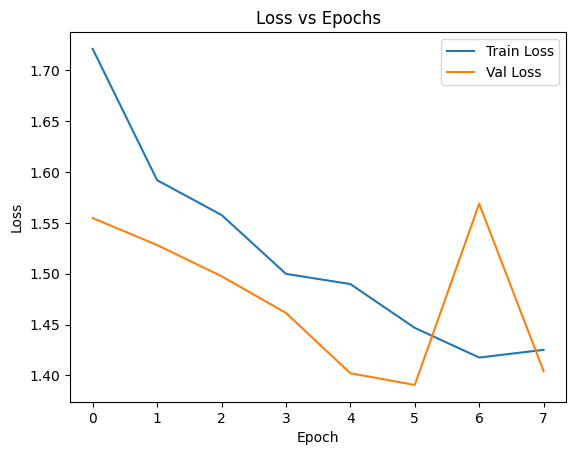

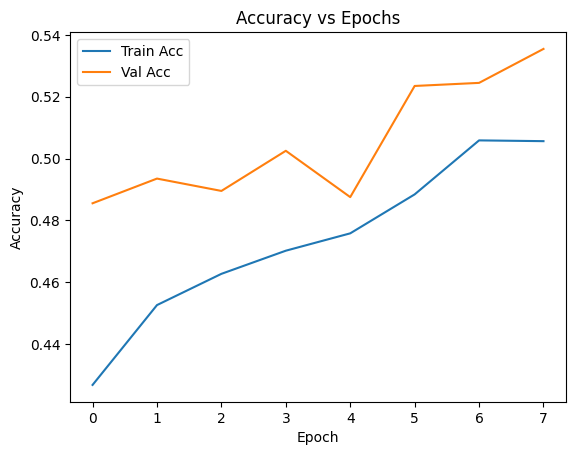

In [16]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()

## Test Evaluation (load best checkpoint)
Includes confusion matrix + classification report.

✅ Loaded best checkpoint from epoch 6 (val_loss=1.3906)
✅ Baseline CNN Test Accuracy: 0.521
✅ Baseline CNN Test Macro F1: 0.3489


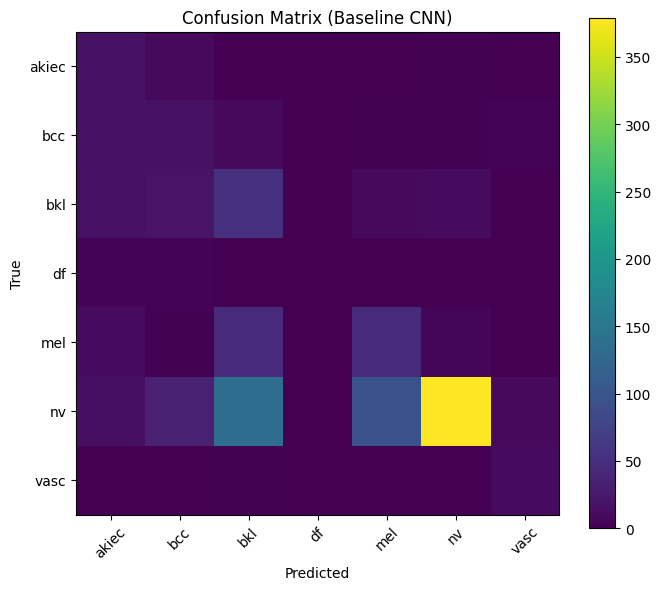


Classification Report:
              precision    recall  f1-score   support

       akiec       0.22      0.56      0.31        32
         bcc       0.19      0.33      0.24        52
         bkl       0.21      0.46      0.29       110
          df       0.00      0.00      0.00        11
         mel       0.30      0.41      0.34       112
          nv       0.95      0.56      0.71       671
        vasc       0.42      0.79      0.55        14

    accuracy                           0.52      1002
   macro avg       0.33      0.44      0.35      1002
weighted avg       0.71      0.52      0.57      1002



In [17]:
# Load best checkpoint
ckpt = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✅ Loaded best checkpoint from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    all_preds = []
    all_true = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)

y_true, y_pred = predict_all(model, test_loader, device)

test_acc = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("✅ Baseline CNN Test Accuracy:", round(test_acc, 4))
print("✅ Baseline CNN Test Macro F1:", round(test_macro_f1, 4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (Baseline CNN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

## Baseline Results Table (Rubric)
Your models should beat naive baselines to demonstrate value.

In [18]:
baseline_table = pd.concat([
    baseline_table,
    pd.DataFrame([{"Baseline": "Baseline CNN (weighted CE)", "Accuracy": test_acc, "Macro F1": test_macro_f1}])
], ignore_index=True)

baseline_table.sort_values(by="Accuracy", ascending=False)

,Baseline,Accuracy,Macro F1
1,Majority class,0.669661,0.114593
3,Baseline CNN (weighted CE),0.520958,0.348887
2,LogReg (32x32 gray),0.430140,0.201088
0,Random (uniform),0.153693,0.086798


In [19]:
import pandas as pd

results_data = {
    "model": ["Random", "Majority", "LogisticRegression", "BaselineCNN"],
    "accuracy": [
        baseline_table.loc[baseline_table["Baseline"]=="Random (uniform)","Accuracy"].values[0],
        baseline_table.loc[baseline_table["Baseline"]=="Majority class","Accuracy"].values[0],
        baseline_table.loc[baseline_table["Baseline"]=="LogReg (32x32 gray)","Accuracy"].values[0],
        test_acc
    ],
    "macro_f1": [
        baseline_table.loc[baseline_table["Baseline"]=="Random (uniform)","Macro F1"].values[0],
        baseline_table.loc[baseline_table["Baseline"]=="Majority class","Macro F1"].values[0],
        baseline_table.loc[baseline_table["Baseline"]=="LogReg (32x32 gray)","Macro F1"].values[0],
        test_macro_f1
    ]
}

results_df = pd.DataFrame(results_data)

results_path = PROJECT_ROOT / "results" / "baseline_results.csv"
results_df.to_csv(results_path, index=False)

print("✅ Results saved to:", results_path)
display(results_df)

✅ Results saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/baseline_results.csv


,model,accuracy,macro_f1
0,Random,0.153693,0.086798
1,Majority,0.669661,0.114593
2,LogisticRegression,0.430140,0.201088
3,BaselineCNN,0.520958,0.348887


## Baseline Model Conclusion

This notebook established baseline performance for the HAM10000 skin lesion classification task using several progressively more informative models.

Random and majority-class baselines were first evaluated to understand the effect of dataset imbalance. While the majority-class predictor achieved relatively high accuracy due to the dominance of the *nevus (nv)* class, its macro F1 score was very low, indicating poor performance on minority classes.

A simple machine learning baseline using Logistic Regression on low-resolution grayscale images achieved moderate performance (Accuracy ≈ 0.43, Macro F1 ≈ 0.20), demonstrating that some predictive signal exists in the data but that spatial image features are not fully captured.

A baseline Convolutional Neural Network (CNN) was then trained on the full images with class-weighted cross-entropy to address class imbalance. The model achieved:

- **Test Accuracy:** 0.52  
- **Macro F1 Score:** 0.35  

The CNN substantially improved macro F1 compared to the naive and simple baselines, indicating better recognition of minority lesion types.

However, the confusion matrix shows that rare classes remain difficult to classify and that performance is still influenced by class imbalance. These results motivate the use of **transfer learning with pretrained convolutional networks**, which can leverage richer visual representations to improve classification performance.

The next notebook explores transfer learning approaches to improve performance beyond this baseline.